<a href="https://colab.research.google.com/github/mahamatsouleymane-creator/ML-Manuel-lab/blob/lab-10/MLlab1o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# LAB EXERCISE 10: LEARNING THE XOR BOOLEAN FUNCTION USING AN MLP

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
#  CREATE DATASET

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print("Inputs (X):\n", X)
print("Outputs (y):\n", y)

# Decision boundary visualization helper
def plot_decision_boundary(predict_fn, X, y, title="Decision Boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    preds = predict_fn(grid)
    preds = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 4.5))
    plt.contourf(xx, yy, preds, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.8)
    plt.colorbar(label="Prediction Probability")

    for i in range(len(y)):
        if y[i] == 0:
            plt.scatter(X[i, 0], X[i, 1], color='red', edgecolor='k', s=150, marker='o', label='Class 0' if i==0 else "")
        else:
            plt.scatter(X[i, 0], X[i, 1], color='blue', edgecolor='k', s=150, marker='^', label='Class 1' if i==1 else "")

    plt.title(title)
    plt.xlabel("Input 1 ($X_1$)")
    plt.ylabel("Input 2 ($X_2$)")
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()


Inputs (X):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Outputs (y):
 [[0.]
 [1.]
 [1.]
 [0.]]



=== 1. KERAS IMPLEMENTATION ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Keras Predictions:
Input: [0. 0.] | Target: 0 | Prob: 0.0001 | Pred Class: 0
Input: [0. 1.] | Target: 1 | Prob: 0.9976 | Pred Class: 1
Input: [1. 0.] | Target: 1 | Prob: 0.9981 | Pred Class: 1
Input: [1. 1.] | Target: 0 | Prob: 0.0035 | Pred Class: 0


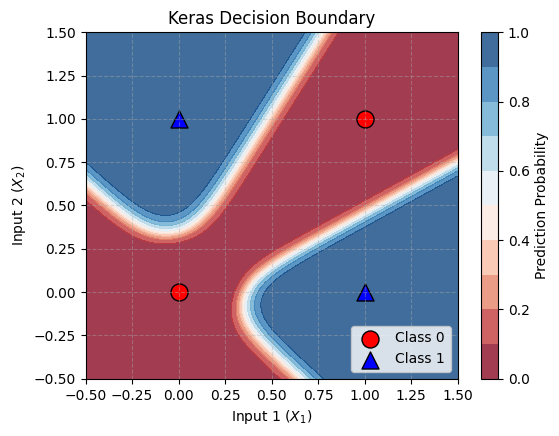

In [ ]:
#  KERAS HIGH-LEVEL API
# ------------------------------------------------------------------------------
print("\n=== 1. KERAS IMPLEMENTATION ===")
keras_model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_keras = keras_model.fit(X, y, epochs=500, verbose=0)
preds_keras = keras_model.predict(X)

print("\nKeras Predictions:")
for i in range(4):
    print(f"Input: {X[i]} | Target: {int(y[i][0])} | Prob: {preds_keras[i][0]:.4f} | Pred Class: {1 if preds_keras[i][0]>=0.5 else 0}")

plot_decision_boundary(lambda g: keras_model.predict(g, verbose=0), X, y, title="Keras Decision Boundary")


=== 2. TENSORFLOW LOW-LEVEL API IMPLEMENTATION ===

TensorFlow Low-Level Predictions:
Input: [0. 0.] | Target: 0 | Prob: 0.0001 | Pred Class: 0
Input: [0. 1.] | Target: 1 | Prob: 0.9974 | Pred Class: 1
Input: [1. 0.] | Target: 1 | Prob: 0.9995 | Pred Class: 1
Input: [1. 1.] | Target: 0 | Prob: 0.0024 | Pred Class: 0


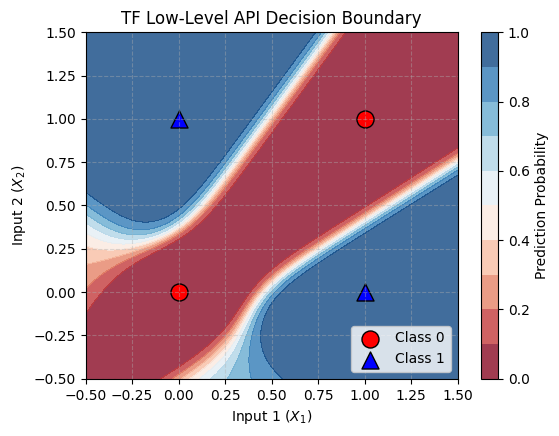

In [ ]:
#  TENSORFLOW LOW-LEVEL API (tf.GradientTape)
# ------------------------------------------------------------------------------
print("\n=== 2. TENSORFLOW LOW-LEVEL API IMPLEMENTATION ===")
W1 = tf.Variable(tf.random.normal([2, 4], stddev=0.5))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4, 1], stddev=0.5))
b2 = tf.Variable(tf.zeros([1]))

def forward_pass(X_in):
    h = tf.nn.tanh(tf.matmul(X_in, W1) + b1)
    out = tf.nn.sigmoid(tf.matmul(h, W2) + b2)
    return out

def compute_loss(y_true, y_pred):
    eps = 1e-7
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))

optimizer = tf.optimizers.Adam(learning_rate=0.05)
for epoch in range(500):
    with tf.GradientTape() as tape:
        preds = forward_pass(X)
        loss = compute_loss(y, preds)
    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))

final_tf_preds = forward_pass(X).numpy()
print("\nTensorFlow Low-Level Predictions:")
for i in range(4):
    print(f"Input: {X[i]} | Target: {int(y[i][0])} | Prob: {final_tf_preds[i][0]:.4f} | Pred Class: {1 if final_tf_preds[i][0]>=0.5 else 0}")

plot_decision_boundary(lambda g: forward_pass(g).numpy(), X, y, title="TF Low-Level API Decision Boundary")

In [ ]:
#  PYTORCH / PURE NUMPY IMPLEMENTATION
# ------------------------------------------------------------------------------
print("\n=== 3. PYTORCH IMPLEMENTATION ===")
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim

    X_pt = torch.tensor(X, dtype=torch.float32)
    y_pt = torch.tensor(y, dtype=torch.float32)

    class PyTorchXOR(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(2, 4)
            self.act = nn.Tanh()
            self.fc2 = nn.Linear(4, 1)
            self.sig = nn.Sigmoid()
        def forward(self, x):
            return self.sig(self.fc2(self.act(self.fc1(x))))

    model_pt = PyTorchXOR()
    criterion = nn.BCELoss()
    opt_pt = optim.Adam(model_pt.parameters(), lr=0.05)

    for epoch in range(500):
        opt_pt.zero_grad()
        out = model_pt(X_pt)
        l = criterion(out, y_pt)
        l.backward()
        opt_pt.step()

    preds_pt = model_pt(X_pt).detach().numpy()
    print("\nPyTorch Predictions:")
    for i in range(4):
        print(f"Input: {X[i]} | Target: {int(y[i][0])} | Prob: {preds_pt[i][0]:.4f} | Pred Class: {1 if preds_pt[i][0]>=0.5 else 0}")

except ImportError:
    print("PyTorch not installed. Using pure NumPy implementation.")


=== 3. PYTORCH IMPLEMENTATION ===

PyTorch Predictions:
Input: [0. 0.] | Target: 0 | Prob: 0.0001 | Pred Class: 0
Input: [0. 1.] | Target: 1 | Prob: 0.9988 | Pred Class: 1
Input: [1. 0.] | Target: 1 | Prob: 0.9969 | Pred Class: 1
Input: [1. 1.] | Target: 0 | Prob: 0.0029 | Pred Class: 0
